# Do Equity Signals Add to Corporate Bond Factors?

## Summary

The fixed six-signal combination has no clear advantage over reducing bond exposure.
An exploratory conditional regression reveals opposing issuer-signal effects:
equity momentum alpha is 3.93%, value alpha is −2.33%, and composite alpha is
inconclusive at 0.60% (95% interval −0.10% to +1.29%). These are annualized gross
intercepts, not feasible hedged returns. The later combined-minus-risk-control mean
is −13.71 bps/year, with a −51.62 to +24.19 interval.

The source-table replication matches 4,092 values. The original fixed combination
has a 0.13% annual mean and 0.05 Sharpe over 231 months, September 2002–November 2021.
The lagged risk control uses 60 training months and 171 comparison months.

[Repository overview](README.md) · [Protocol](research/PROTOCOL.md) · [Sources](research/SOURCES.md)

## Context and methods

This is an individual research replication and extension using public author-released
bond factor returns. The chapters distinguish attributed literature findings from
new calculations. The calculation appendix reruns the study from the cached source archives.

### Key assumptions

Six fixed economic directions; no performance-selected weights; gross long–short
returns per fixed long-side notional; common monthly observations; six-lag HAC inference.
Historical revisions and literature selection limit out-of-sample interpretation.
The 16 September 2026 amendment was designed after inspecting the original results.
It adds conditional controls, a lagged risk benchmark, paired uncertainty and cost
headroom. Its statistical families do not correct for all prior research choices.


## 1. Data: a TRACE return study with explicit source boundaries

[Overview](README.md) · [Next: Factors](docs/02-factors.md)

## The empirical unit

The current study observes **monthly long–short bond factor returns** supplied by external researchers. Each column represents a portfolio formed from a bond or issuer characteristic. Rows contain decimal returns at month-end: 0.01 means 1%.

This unit supports factor replication, combination, risk regressions, and time-series inference. It does not reveal each bond's holdings, point-in-time eligibility, transaction price, or issuer exposure.

## Sources and coverage

| Input | Available period | Monthly rows | Role |
|---|---|---:|---|
| ExcessLongShortVW_DFPS.csv | Sep 2002–Nov 2021 | 231 | Primary TRACE-derived return series |
| ExcessLongShortVW_OSBAP.csv | Sep 2002–Sep 2022 | 241 | Alternative source sensitivity |
| ExcessLongShortVW_ICE.csv | Aug 2002–Nov 2022 | 244 | ICE return-source sensitivity |
| DurAdjLongShortVW.csv | Restricted here to the common period | 231 used | Separate ICE duration-adjusted comparison |
| traded_bond_excess.csv: MKTB, TERM | Jan 1986–Dec 2022 | 444 | Public market and Treasury benchmark series |

The first three files contain the same 341 signal names and are distributed with an [author comparison script and reference table](https://openbondassetpricing.com/wp-content/uploads/2025/07/ExcessLongShortVW_All_Databases.zip). The DFPS label identifies Dick-Nielsen, Feldhütter, Pedersen, and Stolborg's return source. The archive's labels are retained throughout the result tables.

The characteristics are not all constructed from TRACE. The provider documents ICE/BAML bond predictors and equity characteristics from Open Source Asset Pricing and Global Factor Data. Thus **TRACE-derived returns paired with externally constructed signals** describes this study more precisely than “a pure TRACE strategy.” [Provider documentation](https://openbondassetpricing.com/machine-learning-data/)

The separate [co-pricing archive](https://openbondassetpricing.com/wp-content/uploads/2025/12/djm_data.zip) supplies MKTB, the corporate bond market excess return, and TERM, a long-government-bond return less the one-month bill rate. These are published benchmark series, not a market index reconstructed from the DFPS investment universe. Their definitions are in [The Co-Pricing Factor Zoo, Appendix A](https://arxiv.org/html/2604.04430v1#A1).

## Sample construction

The primary comparison uses the intersection of all six selected signals, all three return sources, and both benchmarks:

- Full sample: **September 2002–November 2021, 231 months**.
- Development segment: September 2002–January 2016, 161 months.
- Final chronological evaluation: February 2016–November 2021, 70 months.
- Original-project period overlap: January 2013–November 2021, 107 months.

No 2022–2023 primary results are implied. Comparisons use identical dates. There is no missing-value imputation, return clipping, or selection based on observed profitability.

## Checks performed

[Data-quality results](research/results/data_quality.csv) record zero duplicate months and zero missing observations in the six selected series for every source. The full archives do contain missing values: 257 cells for DFPS, 252 for OSBAP, and 251 for ICE. Those observations are handled pairwise in the author-table replication; they never enter the balanced six-signal study.

The analysis verifies:

- Month-end dates, unique months, and a contiguous common sample.
- Finite observed returns and the presence of each expected signal.
- Source checksums against the [download manifest](research/data/source_manifest.json).
- Exact author-table replication, before changing factor orientation.
- Consistent orientation restoration independently for each file, including duration-adjusted factors.

Large returns remain in the sample. The study does not independently certify the quality of every underlying bond transaction.

## What cannot be inferred

The factor files do not permit rebuilding issuer-balanced portfolios, an investment-grade-only universe, or rating/duration-neutral holdings. Public bond panels also omit proprietary fields such as ratings and GVKEYs; the predictor panel requires a separate bond-return merge. [Public panel scope](https://openbondassetpricing.com/data/)

The completed empirical scope therefore uses factor series. Security-level tercile construction remains an extension requiring matched identifiers, point-in-time signals, and eligible returns. No claim of security-level replication is made.

## Requirements for a security-level extension

For a future security-level reconstruction, total return must account separately for beginning and ending accrued interest and actual cash payments:

$$
R_{i,t+1} =
\frac{P_{i,t+1}+AI_{i,t+1}+C_{i,t+1}}{P_{i,t}+AI_{i,t}}-1.
$$

The current analysis consumes authors' portfolio returns and does not reconstruct
security-level total returns. TRACE is operated by [FINRA](https://www.finra.org/filing-reporting/trace).

## Files and recovery

The 16 September amendment uses the same archived factor returns and benchmarks.
Its observation remains a **factor-month**, not a bond, issuer, trade, or announcement.
The risk-control study loses the first 60 months to its training window and compares
all strategies over September 2007–November 2021 (171 months), or February
2016–November 2021 (70 months). No current-month return enters its scaling weight.
The conditional-alpha study retains the original 231-month common sample.

Consequently, the new regressions cannot identify which issuers drove equity momentum,
whether announcement information preceded a trade, or whether stale prices generated
the effect. Those are questions for a matched panel, not missing columns to infer here.

[download_sources.py](research/download_sources.py) caches three numerical archives in research/data/raw/. Those files are ignored by Git. [run_study.py](research/run_study.py) generates the balanced return panels and statistical outputs. All derived returns remain decimal; displayed percentages are explicitly labeled.

Rerun the downloader after an interrupted transfer; it restarts the partial archive and retains completed files. Rerun the analysis from the cached files to regenerate results. The [source register](research/SOURCES.md) records the publications and precise evidence used.


## 2. Factors: replication before interpretation

[Data](docs/01-data.md) · [Next: Portfolio construction](docs/03-portfolios.md)

## Research hypotheses

The main question is **whether issuer equity information adds positive conditional
alpha beyond existing bond signals**. A portfolio average alone cannot answer this:
it can conceal offsetting signals and changes in risk. The initial hypotheses remain:

1. Credit spreads, past bond returns, and bond volatility may capture different credit exposures.
2. Issuer equity momentum, valuation, and profitability may contain information relevant to creditors.
3. Combining the groups may improve diversification and incremental performance.

These are hypotheses, not assertions that high characteristic values always earn higher returns. A characteristic is an input used to sort securities; a factor return is the return of that sorted portfolio; a regression beta is its estimated exposure to another return series. The study keeps these objects separate.

## Six fixed signals

| Signal | Source column in primary archive | Characteristic | Chosen long side | Multiply stored return by |
|---|---|---|---|---:|
| Credit spread | VW_18_spread | Bond option-adjusted spread | Higher spread | +1 |
| Bond momentum | VW_12_mom6* | Prior six-month bond return sum, excluding most recent month | Past winners | −1 |
| Low volatility | VW_27_volatility | Rolling bond-return volatility | Lower volatility | −1 |
| Equity momentum | VW_ret_6_1 | Issuer equity price momentum, excluding most recent month | Past winners | +1 |
| Equity value | VW_be_me | Issuer book equity / market equity | Higher book-to-market | +1 |
| Equity profitability | VW_gp_at* | Issuer gross profits / assets | More profitable issuers | −1 |

Bond definitions follow [Factor Investing with Delays, Table A.1](https://www.ier.hit-u.ac.jp/Common/publication/DP/DPS-A771.pdf). Volatility uses a window expanding from 12 observations to 36. Equity definitions follow [Global Factor Data documentation](https://jkpfactors-data.s3.amazonaws.com/documents/Documentation.pdf), including ret_6_1, be_me, and gp_at.

The [initial protocol](research/PROTOCOL.md) records these concepts and economic
directions; no independently timestamped preregistration is established by this working
tree. Low volatility is a deliberately tested defensive hypothesis, not a recommendation
to reverse the observed high-volatility premium. The 16 September diagnostics were
added after the original results were inspected and are explicitly exploratory.

### Recovering factor direction

An asterisk marks a factor flipped by the provider to produce a positive historical premium. For the economic-direction study:

$$
f^{economic}_{j,t}=d_j s_j f^{stored}_{j,t},
\qquad s_j=-1\text{ for starred columns, }+1\text{ otherwise}.
$$

Here d is +1 for a high-minus-low characteristic strategy and −1 for low volatility. Low volatility reverses an unstarred high-volatility return; bond momentum and profitability undo starred reversals. The machine-readable [mapping](research/results/signal_mapping.csv) makes both operations explicit. The [provider documents the sign convention](https://openbondassetpricing.com/machine-learning-data/).

This choice matters: the combined portfolio's source-oriented mean is 3.71% annually and Sharpe is 0.66; the economic-direction version has a 0.13% mean and 0.05 Sharpe. These portfolios differ in their actual exposures. The comparison does not isolate all forms of look-ahead bias or establish that every source factor is biased.

## What is reproduced

The July 2025 archive includes DatabaseComparison_DNR_2022.csv and database_comparison.py. I independently recompute its 341-factor comparison: three correlations, three monthly means, three annualized Sharpe ratios, and three paired-test p-values for each factor.

**All 4,092 values match, with maximum absolute error 7.22 × 10⁻¹⁶.** This validates reproduction of the archived summary table, not the original transaction-level construction.

| Stored factor | Reported monthly mean | Recomputed monthly mean | Reported / recomputed Sharpe |
|---|---:|---:|---:|
| Credit spread | 0.829182% | 0.829182% | 0.688813 / 0.688813 |
| Bond momentum* | 0.163064% | 0.163064% | 0.174137 / 0.174137 |
| High volatility | 0.695125% | 0.695125% | 0.784686 / 0.784686 |
| Equity momentum | 0.052435% | 0.052435% | 0.079462 / 0.079462 |
| Equity value | 0.076900% | 0.076900% | 0.122507 / 0.122507 |
| Equity profitability* | 0.036093% | 0.036093% | 0.095786 / 0.095786 |

*DFPS, September 2002–November 2021, authors' stored orientation. The replication retains the authors' paired iid t-tests; the extension uses HAC inference. [Exact comparison](research/results/replication_selected.csv)*

## How the literature informs this study

The [source register](research/SOURCES.md) separates published findings from calculations performed here.

- **Priced Risk in Corporate Bonds:** corrected temporal alignment weakens several established factors' incremental pricing evidence. This motivates an explicit market benchmark.
- **Corporate Bond Factors: Replication Failures and a New Framework:** reports surviving bond and equity-derived signals under its construction. This motivates studying issuer information, without assuming that all equity styles transfer.
- **Factor Investing with Delays:** studies how infrequent execution affects factor economics. This prevents equating gross factor performance with implementable alpha.
- **The Corporate Bond Factor Replication Crisis:** examines shared-price measurement error, future-dependent filtering, and construction sensitivity. This motivates transparent signs, fixed definitions, and source comparisons.
- **The Co-Pricing Factor Zoo:** studies a substantially larger joint bond/equity pricing model. This six-signal strategy does not reproduce or contradict that model merely by producing a weak result.

## Estimation

For each of the six signals, three composites, and the combined-minus-bond contrast:

$$
f_t=\alpha+\beta_M MKTB_t+\varepsilon_t,
\qquad
f_t=\alpha+\beta_M MKTB_t+\beta_T TERM_t+\varepsilon_t.
$$

OLS uses the full stated sample or segment, with Newey–West covariance, six lags, Bartlett weights, and the n/(n−k) finite-sample adjustment. Tests use the asymptotic normal distribution. Confidence intervals are pointwise 95% intervals.

Benjamini–Hochberg q-values are computed separately for ten mean tests, ten market-alpha tests, and ten market-plus-TERM-alpha tests within each dataset/segment. Correlated factors and multiple sensitivity exercises mean these are defined-family adjustments, not a universal correction for all research choices.

The regressions check that observations are sufficient and the design matrix has full rank.

## New question: incremental information conditional on bond factors

For each equity-derived bond factor and their equal-weight composite, estimate:

$$
E_{j,t}=\alpha_j+\gamma_{1j}f_{spread,t}+\gamma_{2j}f_{bondmom,t}
+\gamma_{3j}f_{lowvol,t}+\beta_{Mj}MKTB_t+\beta_{Tj}TERM_t+\epsilon_{j,t}.
$$

The composite is the primary target; the three components explain its result.
The mechanism hypothesis is that issuer information contains credit-relevant variation
beyond these bond portfolios. A nonzero intercept is conditional evidence against this
particular linear return model, not proof of the mechanism, complete mean-variance
spanning, or a pricing error in an individual bond. Contemporaneous regression
coefficients are estimated in each stated sample; they are not a feasible trading rule.

The [amendment](research/PROTOCOL.md) fixes HAC lags 6, with 3 and 12 as sensitivity
checks; full, development, and evaluation segments; and all three return sources.
BH families contain the four targets within each dataset/segment/bandwidth. The
composite overlaps its components, so these are dependent diagnostics. No correction
for all prior research choices is claimed.

The [results](research/results/incremental_spanning.csv) include intervals, p- and
q-values, R², residual volatility, and a condition number after standardizing controls.
Full-sample DFPS conditional alphas are 3.93% for equity momentum, −2.33% for value,
and 0.20% for profitability; their average is the composite's 0.60%. The economic
directions and original portfolio weights remain unchanged. A negative value estimate
does not authorize turning it into a successful short-value strategy after inspection.


## 3. Portfolio construction: combining bond and issuer information

[Factors](docs/02-factors.md) · [Next: Evaluation](docs/04-evaluation.md)

## The object being traded

Every sleeve is a **corporate bond long–short factor portfolio**. “Equity-derived” means that issuer equity information determines which bonds enter the portfolios. It does not mean buying stocks or averaging stock returns with bond returns.

The underlying author portfolios are monthly, value-weighted extreme-decile sorts. This study combines their published return series. It does not recover security holdings or claim that the resulting trades were executable.

## Fixed weights

Let B contain credit spread, bond momentum, and low volatility, and E contain equity momentum, equity value, and equity profitability. After applying the documented directions:

$$
B_t=\frac{f_{spread,t}+f_{bondmom,t}+f_{lowvol,t}}{3},
\qquad
E_t=\frac{f_{eqmom,t}+f_{eqvalue,t}+f_{eqprofit,t}}{3},
$$

$$
C_t=\frac{B_t+E_t}{2},
\qquad
\Delta_t=C_t-B_t=\frac{E_t-B_t}{2}.
$$

Each signal has a one-sixth weight in the combined strategy. The original strategy
has no estimated expected-return model, optimized allocation, volatility target, or
reweighting based on subsequent returns. The amendment scales a separate comparison
portfolio using prior volatility. Missing signals cause an error rather than a silent
change in portfolio composition.

The contrast Δ directly asks whether the combined portfolio improves average return over the bond-only portfolio. Comparing two Sharpe ratios by inspection does not answer that question statistically.

## Why diversification may help—and why it may disappoint

![Signal correlations](research/figures/signal_correlations.png)

Credit spread and low volatility have a **−0.88** monthly correlation. Equity momentum and equity value correlate at **−0.76**. These relationships show substantial offsetting exposures.

Equal signal weights therefore do not imply equal risk contributions or six independent sources of alpha. Credit spread has a 9.95% annual mean in the primary sample, but low volatility has −8.34%. Their offset contributes to the bond-only portfolio's small mean. That is a consequence of the fixed hypotheses, not a reason to choose their signs again after observing performance.

The combined portfolio reduces annual volatility from **3.47%** for bond-only to **2.53%**. Its average-return increase is **0.24 percentage points**, with a 95% HAC interval of **−0.41 to +0.90 percentage points**. Diversification is observed; reliable incremental average return is not established.

## New comparison: would reducing bond exposure achieve a similar result?

Lower volatility alone is an incomplete case for adding another signal family.
Construct a control using only the preceding 60 months:

$$
w_t=\min\left(1,\max\left(0,\frac{\widehat\sigma(C_{t-60:t-1})}
{\widehat\sigma(B_{t-60:t-1})}\right)\right),
\qquad B^{control}_t=w_tB_t.
$$

The reference notional is constant; the amount assigned to the bond sleeve varies.
Unused notional contributes zero excess P&L. No cash yield, borrowing or collateral
return is modeled. The cap avoids levered control weights. Forecast volatility ratios
do not ensure equal realized volatility, so both are reported. This control is a
diagnostic for reducing exposure, not a claim of an exactly risk-matched investable fund.

The first 60 months are a warmup for **all** comparisons. The remaining 171 months
start in September 2007; the original later segment remains February 2016–November
2021. Locally generated `research/results/risk_control_returns_*.csv` files
save weights, unclipped ratios and the last training date; the public tree retains
[summary performance](research/results/risk_control_performance.csv).
Tests change current and
future returns to verify that the current weight cannot change.

Use paired mean differences and paired Sharpe intervals. Bootstrap draws resample
both realized paths together in circular blocks of 6 or 12 months, retaining their
contemporaneous dependence. The 5,000-draw percentile intervals are conditional on
realized weights; they do not refit the rule or account for research selection and
structural breaks. They are descriptive uncertainty checks, not a studentized test.

## Security-level integration remains a different experiment

This completed study tests **mixing existing factor portfolios**. A true integrated strategy would combine characteristics before selecting bonds, allowing overlapping positions to net at the security level.

Lower turnover and better performance from security-level integration are not established here. Testing them requires bond-level identifiers, dated characteristics, holdings, and rebalancing rules. Aggregate factor-return files cannot reveal turnover savings or issuer concentration.

A future security-level comparison should use the same universe and information dates for both constructions, carry signal observations forward only when available, and measure one-month-ahead returns. It should compare issuer-balanced and bond-weighted results and control duration, rating, and liquidity exposures where the data permit.

## Return and capital conventions

The factor return is a long-minus-short spread. Reported annual means equal twelve times the monthly mean. Cumulative charts sum monthly returns on fixed notional; they do not show compound growth of investable wealth.

Drawdown is the decline in cumulative P&L from its running peak, including a zero-P&L starting point, expressed relative to fixed long-side notional. It is not a fund NAV drawdown. A single factor can lose more than 100% of that notional over time because collateral, financing, and liquidation constraints are not modeled.

Fees, bid–ask spreads, borrowing costs, and trade delays are absent. The [evaluation](docs/04-evaluation.md) includes transparent annual cost hurdles rather than an estimated net backtest.

[Strategy summary statistics](research/results/performance.csv) · [Construction and estimation code](research/run_study.py)


## 4. Evaluation: distinguish signal evidence from an allocation decision

[Portfolio construction](docs/03-portfolios.md) · [Next: Applications](docs/05-applications.md)

## Main result

**The new controls support a narrower allocation conclusion and a sharper follow-up.**
The equity composite has inconclusive alpha after conditioning on individual bond
factors. Its components differ: momentum is positive and value negative. Combining
all six factors has no clear advantage over reducing bond exposure. The following
amendment results are exploratory and use history already inspected in the original
study; the original fixed-combination results are retained below.

## Conditional alpha: what the portfolio average concealed

| Equity-derived target | Full alpha | 95% HAC interval | Full BH q | Later alpha | Later BH q |
|---|---:|---:|---:|---:|---:|
| Equal-weight composite | 0.60% | −0.10% to 1.29% | 0.123 | 0.19% | 0.522 |
| Momentum | 3.93% | 2.04% to 5.81% | 0.00018 | 2.91% | 0.010 |
| Value | −2.33% | −3.97% to −0.69% | 0.011 | −1.44% | 0.010 |
| Profitability | 0.20% | −1.33% to 1.73% | 0.801 | −0.91% | 0.063 |

*DFPS; full sample 231 months, later sample 70 months. Annualized gross intercepts
conditional on credit spread, bond momentum, low volatility, MKTB and TERM. Six-lag
HAC; four-test BH families within each segment. These differ from the market/TERM-only
regressions below. [Exact estimates and bandwidth checks](research/results/incremental_spanning.csv)*

![Conditional issuer-signal alpha](research/figures/incremental_alpha.png)

The new benchmark changes the inference materially: equity momentum's full-sample
q-value is 0.00018 under this model, versus 0.244 under the original market/TERM-only
model and its different testing family. Benchmark choice and the testing family both
matter. A favorable conditional alpha need not imply a positive standalone return or
an executable hedge; coefficients here are estimated contemporaneously in each sample.
This is evidence for a focused follow-up, not permission to select a winning strategy.

Across DFPS, OSBAP and ICE, the composite's full conditional alpha is 0.60%, 0.43% and
0.67%; each six-lag 95% interval includes zero. Momentum is positive and passes the
defined 5% BH threshold in full and later samples across all three. The shared source
inputs and reused history prevent treating this as independent discovery replication.

## A control that reduces bond exposure using prior information

| Period | Strategy | Annual mean | Annual volatility | Sharpe |
|---|---|---:|---:|---:|
| Sep 2007–Nov 2021, 171 months | Combined | −0.12% | 2.69% | −0.044 |
| Same dates | Bond-only | −0.19% | 3.64% | −0.053 |
| Same dates | Risk-scaled bond | −0.21% | 2.76% | −0.076 |
| Feb 2016–Nov 2021, 70 months | Combined | −0.46% | 2.07% | −0.223 |
| Same dates | Bond-only | −0.54% | 3.13% | −0.173 |
| Same dates | Risk-scaled bond | −0.32% | 2.17% | −0.149 |

The control uses only the preceding 60 months to set its exposure. Its average weight
is 0.724 after warmup and 0.693 in the later segment; the cap never binds in DFPS.
Realized risks are close, not identical. All comparison returns use the same dates
and fixed reference notional. [Construction](docs/03-portfolios.md)
and [exact performance](research/results/risk_control_performance.csv).

Combined-minus-control Sharpe is +0.032 after warmup, with a paired six-month-block
95% percentile interval of −0.121 to +0.192. In the later period it is −0.074
(−0.242 to +0.109). Twelve-month-block intervals also include zero. These descriptive
intervals assume useful within-period stationarity and condition on realized paths;
they do not correct for selection or estimate uncertainty in a freshly refitted rule.
[All paired Sharpe intervals](research/results/sharpe_difference_intervals.csv).

## Incremental cost budget and what the sample can distinguish

| Combined minus risk-scaled bond | Incremental mean | 95% HAC interval | Approx. 80%-power detectable effect |
|---|---:|---:|---:|
| Post-warmup | +9.17 bps/year | −33.65 to +51.98 | 61.20 bps/year |
| Later evaluation | −13.71 bps/year | −51.62 to +24.19 | 54.18 bps/year |

The mean difference is the estimated **additional constant annual cost** the combined
strategy could bear before losing to this control. It is separate from the original
combined strategy's total gross break-even hurdle. Negative headroom is retained,
not reported as zero. Neither turnover nor realized costs are observed.

The amendment sets an illustrative 50-bps/year materiality threshold. The post-warmup
interval includes it, so the result is inconclusive at that threshold. The later
interval's upper bound is below 50 bps, although it still includes zero. Thus the
later data do not support a 50-bps improvement under these assumptions; they do not
prove the strategies equivalent or prove future underperformance. Detectable effects
are normal/HAC precision approximations, not forecast sample-size guarantees.
[Exact cost and precision calculations](research/results/incremental_cost_budget.csv).

## Paired source comparisons

On the full common sample, DFPS-minus-OSBAP combined mean is −2.85 bps/year
(95% HAC interval −19.16 to +13.46); DFPS-minus-ICE is −7.32 bps (−28.62 to +13.99).
Combined monthly return correlations exceed 0.97 for every pair. These comparisons
provide no clear mean-difference evidence at the chosen precision, but do not establish
database equivalence or certify common construction choices. [Paired results](research/results/paired_source_differences.csv).

## Original fixed-combination experiment

The fixed combination of bond and equity-derived signals produces a **0.13% annual arithmetic mean** and **0.05 Sharpe** over September 2002–November 2021. Its market-plus-TERM alpha is **0.61% annually**, with p = **0.343** and BH q = **0.685**. The evidence does not establish positive alpha.

All estimates below are **computed in this repository**, using gross long–short factor returns. Published findings are separately attributed in the [source register](research/SOURCES.md).

## Full sample: 231 months

| Strategy | Annual mean | Annual vol. | Sharpe | Annual alpha¹ | Alpha p | BH q |
|---|---:|---:|---:|---:|---:|---:|
| Bond-only | −0.12% | 3.47% | −0.03 | 0.54% | 0.539 | 0.770 |
| Equity-derived | 0.37% | 2.18% | 0.17 | 0.68% | 0.182 | 0.455 |
| Combined | 0.13% | 2.53% | 0.05 | 0.61% | 0.343 | 0.685 |
| Combined minus bond | 0.24% | 1.40% | 0.17 | 0.07% | 0.825 | 0.888 |

¹ MKTB + TERM regression; six-lag Newey–West covariance. Means and alphas are annualized arithmetically; p- and q-values are two-sided.

The direct improvement in mean return has p = **0.465**. Its annual alpha difference is **0.07%**, with a 95% interval of **−0.55% to +0.69%**. Neither comparison supports a reliable incremental benefit.

![Alpha estimates and uncertainty](research/figures/alpha_intervals.png)

### Individual signals

| Signal | Annual mean | Sharpe | Annual alpha¹ | Alpha p | BH q |
|---|---:|---:|---:|---:|---:|
| Credit spread | 9.95% | 0.69 | 4.82% | 0.010 | 0.100 |
| Bond momentum | −1.96% | −0.17 | −0.87% | 0.758 | 0.888 |
| Low volatility | −8.34% | −0.78 | −2.35% | 0.150 | 0.455 |
| Equity momentum | 0.63% | 0.08 | 2.86% | 0.049 | 0.244 |
| Equity value | 0.92% | 0.12 | −0.95% | 0.421 | 0.701 |
| Equity profitability | −0.43% | −0.10 | 0.12% | 0.888 | 0.888 |

Credit spread has positive nominal alpha evidence, but does not pass the stated 5% BH threshold. None of the ten market-plus-TERM alpha tests passes that threshold. The negative low-volatility mean does pass the separate mean-test family; statistical significance need not indicate a profitable hypothesized direction.

## Chronological stability

| Segment | Dates | Months | Bond-only mean | Equity-derived mean | Combined mean |
|---|---|---:|---:|---:|---:|
| Development | Sep 2002–Jan 2016 | 161 | 0.07% | 0.70% | 0.38% |
| Evaluation | Feb 2016–Nov 2021 | 70 | −0.54% | −0.38% | −0.46% |
| Original-period overlap | Jan 2013–Nov 2021 | 107 | 0.42% | 0.20% | 0.31% |

The evaluation segment contains the final 30% of months, rounded upward. Definitions are fixed, but this is not an untouched out-of-sample discovery test: source data were retrospectively revised and the hypotheses came from published research.

The evaluation-period combined Sharpe is **−0.22** and alpha is **−0.41%**, p = **0.707**. The overlapping 2013-period comparison is a sensitivity check, not an independent validation sample.

## Source and methodology sensitivity

| Combined strategy, same dates | Full-sample mean | Full-sample Sharpe | Evaluation mean |
|---|---:|---:|---:|
| DFPS | 0.13% | 0.05 | −0.46% |
| OSBAP | 0.16% | 0.06 | −0.41% |
| ICE | 0.20% | 0.08 | −0.40% |
| ICE, duration-adjusted returns | 0.54% | 0.23 | −0.43% |

The first three hold the selected concepts and weights constant while changing the supplied return file. Their agreement is not three independent experiments: they share signals, issuers, calendar periods, and substantial underlying information. The duration-adjusted line changes the return definition and is not a TRACE duration hedge.

The full-sample combined alpha p-value remains above 0.30 with Newey–West bandwidths of 3, 6, and 12 months. Equal-versus-value-weighted security portfolios and realistic execution delays cannot be reconstructed from these aggregate inputs. Although the older archive contains a turnover file, it pertains to its source portfolios and does not establish turnover for the combined TRACE strategy after netting.

[Source comparisons and estimates](research/results/performance.csv) · [Duration sensitivity](research/results/duration_sensitivity.csv) · [Bandwidth sensitivity](research/results/hac_sensitivity.csv)

## Costs and drawdowns

The combined portfolio's full-sample maximum cumulative P&L decline is **13.77% of fixed long-side notional**; the corresponding bond-only decline is 17.51%. These are not funded-NAV drawdowns.

| Assumed annual cost hurdle | Combined full-sample annual mean after hurdle |
|---|---:|
| 0 bps | 0.13% |
| 100 bps | −0.87% |
| 200 bps | −1.87% |
| 400 bps | −3.87% |

These deductions are **uncalibrated scenarios**, not measured transaction costs. The gross annual mean leaves only about **12.85 bps** before reaching zero; execution delays and borrow fees require separate measurement. [Scenario calculations](research/results/cost_hurdles.csv)

## Validation and research boundary

The author-table reproduction covers 4,092 statistics. Targeted tests verify economic
signs, missing-factor handling, portfolio arithmetic, initial-loss drawdowns, rank
deficiency, and Newey–West covariance against an independent matrix calculation.
The amendment adds checks for current/future-return leakage, warmup and leverage caps,
monthly alignment, conditional alpha against partial regression, paired block sampling,
and preservation of negative cost headroom. The artifact checker independently
reconstructs primary statistics, conditional alphas, and control weights from the archive.

The analysis does not replicate every published table, prove market efficiency,
estimate causal effects, or reject all equity information in credit. It does not
support a strong investment claim for **this fixed six-signal combination under these
data and definitions**. Positive conditional momentum evidence narrows the next
research question; it does not change the failed allocation case into a successful
strategy. The factor-level diagnostics are complete; execution remains untested.

[Exact outputs](research/results) · [Tests](research/test_study.py) · [Combined notebook](study.ipynb)


## 5. Applications: what the evidence supports

[Evaluation](docs/04-evaluation.md) · [Overview](README.md)

## Research conclusion

The fixed combination does not justify an allocation: it has inconclusive incremental
performance and a negative later mean before costs. The new conditional analysis
identifies a distinction hidden by the average: equity momentum has positive alpha
against the specified bond-factor controls, while equity value has negative alpha.
This is a lead for research, not a tested momentum-only investment strategy.

The useful output is a documented method for deciding whether an apparent credit factor deserves further investigation. It can support research prioritization and risk analysis; it does not yet justify deploying this portfolio.

## Practical uses

### Factor due diligence

Start by reproducing a provider's own statistics. Then inspect its sign conventions, information dates, weighting, return definition, and universe. This project reproduces the source table exactly, yet obtains a much lower combined Sharpe after applying the originally hypothesized directions.

That distinction matters when evaluating a proposed signal: a reproducible historical premium can still depend on an economically different trade or an infeasible construction.

### Credit exposure analysis

Credit spreads and low volatility largely offset in the tested portfolios. Equal signal weights therefore offer an incomplete picture of risk. A portfolio researcher can use the factor correlation matrix and market/TERM regressions as diagnostics before imposing bond-level duration, spread, rating, and issuer constraints.

The regression alpha is conditional on the selected benchmark. It is not a valuation estimate for an individual illiquid bond.

### Equity information in bond research

Issuer equity momentum, valuation, and profitability should not be treated as
interchangeable additions. Equity momentum's original market-plus-TERM alpha has
p = 0.049 and q = 0.244. In the exploratory model that additionally controls for the
three individual bond factors, its annual alpha is 3.93% with q = 0.00018; later
alpha is 2.91% with q = 0.010. These are different conditioning sets and testing
families. The composite's conditional alpha remains inconclusive. A contemporaneous
regression intercept does not establish net returns to a feasible hedge.

Future work should distinguish information about improving issuer fundamentals from compensation for changing credit risk. Bond and equity claims occupy different positions in the capital structure, so an equity-style label alone does not determine the appropriate credit trade.

## Research decision

Do not promote the fixed six-signal combination as a successful strategy. Its later
incremental mean versus the volatility-scaled bond control is −13.71 bps/year, with
a 95% interval ending at +24.19 bps. That provides no support for the amendment's
illustrative 50-bps additional-return requirement under the stated assumptions.

Allocate the next research effort to a narrower question: **does issuer equity
momentum predict bond repricing within comparable credit-risk groups, or is its
conditional alpha explained by risk exposure and stale observations?**

A follow-on experiment requires:

1. A public or licensed bond-month return panel with reliable issuer links, signal availability dates, accrued interest, and cash flows.
2. Lagged bond spread/momentum and issuer equity characteristics, preserving publication lags and missingness.
3. The same eligible universe for bond-only and bond-plus-equity comparisons, across issuers within comparable risk groups.
4. Measured holdings, issuer concentration, duration and rating exposures, turnover, borrowing requirements, and execution-delay sensitivity.
5. A genuinely later evaluation period, with selection rules fixed before its returns are inspected.

Distinguish information transmission from stale-price measurement with fresh-price
subsets and executable entry-delay tests. Merely shifting published factor returns
does not simulate execution. An issuer signal is constant within issuer-month, so
issuer-by-month fixed effects would absorb it. A within-issuer relative-value question
would require bond-specific characteristics instead.

The [next-experiment design](research/RESEARCH_AGENDA.md)
specify the counterfactuals, timing, economic endpoints and missing data. This follow-up
is designed, not run. No ratings, holdings or issuer identifiers are inferred from
aggregate factor returns.

## What this project demonstrates

The research contribution is visible in the sequence from hypothesis to conclusion:

- Independent reproduction of a large published-data comparison.
- Explicit handling of factor direction and mixed data provenance.
- A transparent fixed experiment, followed by a dated exploratory amendment.
- Conditional signal attribution and a benchmark scaled without current-return leakage.
- Paired uncertainty, cost headroom and precision interpreted as a research decision.
- A conclusion that survives adverse results and identifies the evidence needed for a stronger claim.

The project supports a bounded empirical contribution: **a reproducible investigation of how equity information, data choices, and implementation assumptions affect corporate bond factor research.**


## Executed research appendix

### 1. Recompute the evidence

Run `uv sync --locked` and `uv run python research/download_sources.py` first.
The following cell checks source hashes and regenerates all tables and figures.
It performs no network request.

In [1]:
from pathlib import Path
import contextlib
import io
import json
import sys
import pandas as pd
from IPython.display import display, Image

root = Path.cwd()
if not (root / 'research/run_study.py').exists():
    raise RuntimeError('Run this notebook from the repository root')
sys.path.insert(0, str(root / 'research'))
from run_study import main, COMPOSITES
with contextlib.redirect_stdout(io.StringIO()):
    main()
metadata = json.loads((root / 'research/results/study_metadata.json').read_text())
display(pd.Series({k: metadata[k] for k in ['sample_start', 'sample_end', 'months', 'evaluation_start']}))
display(pd.Series(metadata['replication']))

sample_start        2002-09-30
sample_end          2021-11-30
months                     231
evaluation_start    2016-02-29
dtype: object

source                    DatabaseComparison_DNR_2022.csv
factors                                               341
statistics_per_factor                                  12
max_absolute_error                                    0.0
nonmissing_comparisons                               4092
dtype: object

### 2. Inspect primary and later-period performance

Means and alphas below are annualized percentages; Sharpe is unitless.

In [2]:
performance = pd.read_csv(root / 'research/results/performance.csv')
view = performance.loc[
    (performance.dataset == 'DFPS') & performance.strategy.isin(COMPOSITES)
    & performance['sample'].isin(['Full', 'Evaluation']),
    ['sample', 'strategy', 'n', 'annual_mean_pct', 'annual_vol_pct', 'sharpe',
     'market_term_alpha_pct', 'market_term_alpha_p', 'market_term_alpha_q']]
display(view.round(3).reset_index(drop=True))

,sample,strategy,n,annual_mean_pct,annual_vol_pct,sharpe,market_term_alpha_pct,market_term_alpha_p,market_term_alpha_q
0,Full,Bond-only,231,-0.116,3.470,-0.033,0.536,0.539,0.770
1,Full,Equity-derived,231,0.373,2.176,0.171,0.676,0.182,0.455
2,Full,Combined,231,0.128,2.535,0.051,0.606,0.343,0.685
3,Evaluation,Bond-only,70,-0.542,3.130,-0.173,-0.615,0.709,0.856
4,Evaluation,Equity-derived,70,-0.378,1.300,-0.290,-0.211,0.723,0.856
5,Evaluation,Combined,70,-0.460,2.067,-0.223,-0.413,0.707,0.856


### 3. Examine the path and uncertainty

Cumulative P&L uses fixed notional, not compounded fund wealth. Intervals are pointwise HAC intervals.

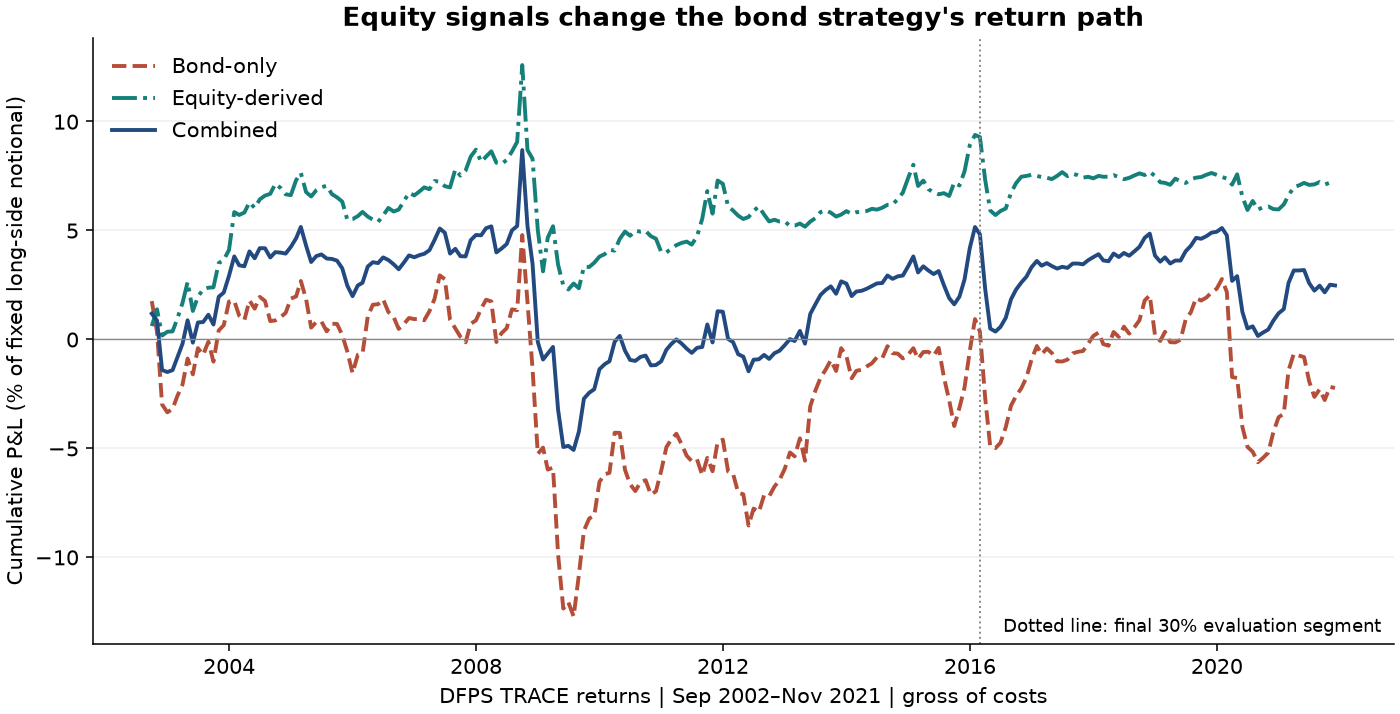

In [3]:
display(Image(filename=str(root / 'research/figures/cumulative_pnl.png')))

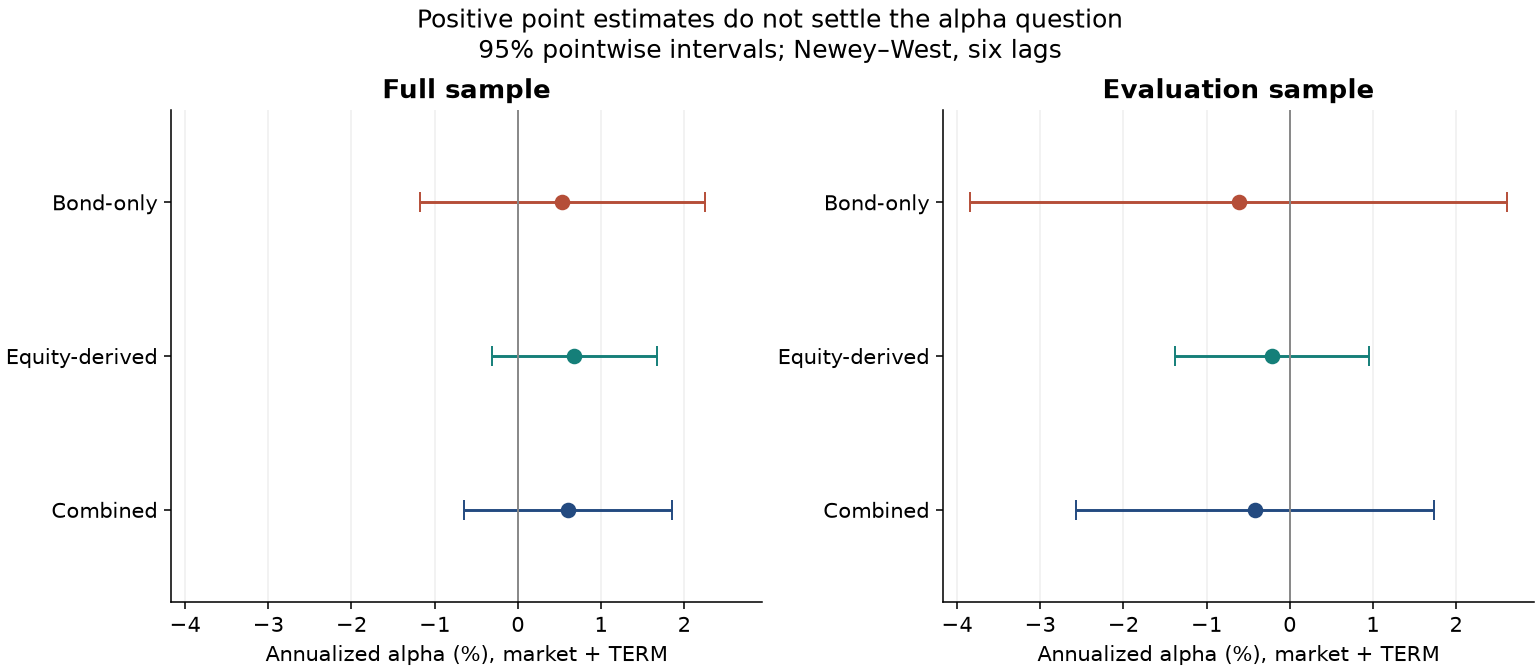

In [4]:
display(Image(filename=str(root / 'research/figures/alpha_intervals.png')))

### 4. Check exposure relationships and orientation

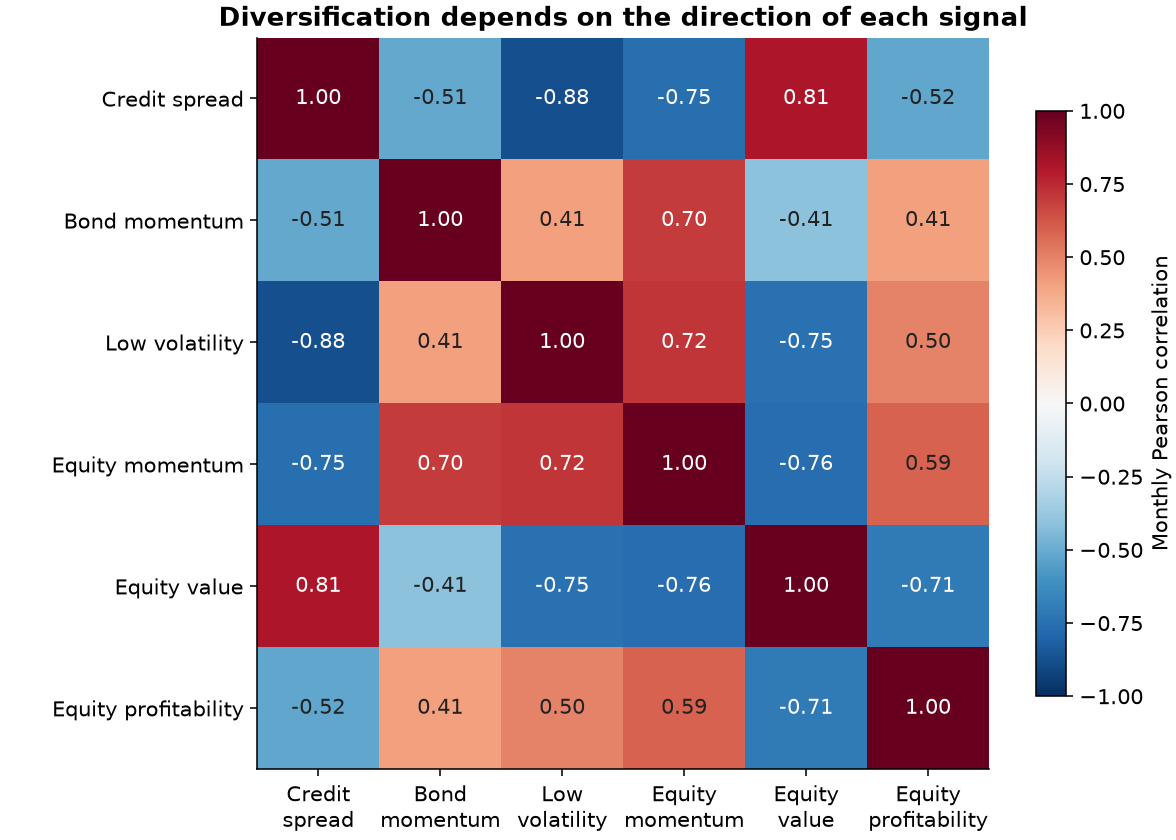

In [5]:
display(Image(filename=str(root / 'research/figures/signal_correlations.png')))

In [6]:
orientation = pd.read_csv(root / 'research/results/orientation_sensitivity.csv')
display(orientation.loc[orientation.strategy.isin(COMPOSITES)].round(3).reset_index(drop=True))

,strategy,source_orientation_mean_pct,economic_orientation_mean_pct,source_orientation_sharpe,economic_orientation_sharpe
0,Bond-only,6.749,-0.116,0.646,-0.033
1,Equity-derived,0.662,0.373,0.268,0.171
2,Combined,3.706,0.128,0.657,0.051


### 5. Incremental issuer information

The new model controls for the three bond factors as well as MKTB and TERM. Intervals
are pointwise; four-test BH families include the composite and its three components.
This is conditional alpha attribution, not a full mean-variance spanning test.

In [7]:
conditional = pd.read_csv(root / 'research/results/incremental_spanning.csv')
view = conditional.loc[(conditional.dataset == 'DFPS') & (conditional.lags == 6)
    & conditional['sample'].isin(['Full', 'Evaluation']),
    ['sample', 'target', 'annual_alpha_pct', 'alpha_ci_low_pct', 'alpha_ci_high_pct', 'alpha_q']]
display(view.rename(columns={'annual_alpha_pct': 'Alpha %/year', 'alpha_ci_low_pct': '95% low',
    'alpha_ci_high_pct': '95% high', 'alpha_q': 'BH q'}).round(4).reset_index(drop=True))

,sample,target,Alpha %/year,95% low,95% high,BH q
0,Full,Equity-derived,0.5974,-0.0979,1.2926,0.1229
1,Full,Equity momentum,3.9256,2.0371,5.8141,0.0002
2,Full,Equity value,-2.3304,-3.9689,-0.6919,0.0106
3,Full,Equity profitability,0.1969,-1.3324,1.7263,0.8007
4,Evaluation,Equity-derived,0.1904,-0.3928,0.7736,0.5223
5,Evaluation,Equity momentum,2.9146,0.9531,4.8761,0.0102
6,Evaluation,Equity value,-1.4378,-2.4440,-0.4317,0.0102
7,Evaluation,Equity profitability,-0.9056,-1.8002,-0.0111,0.0630


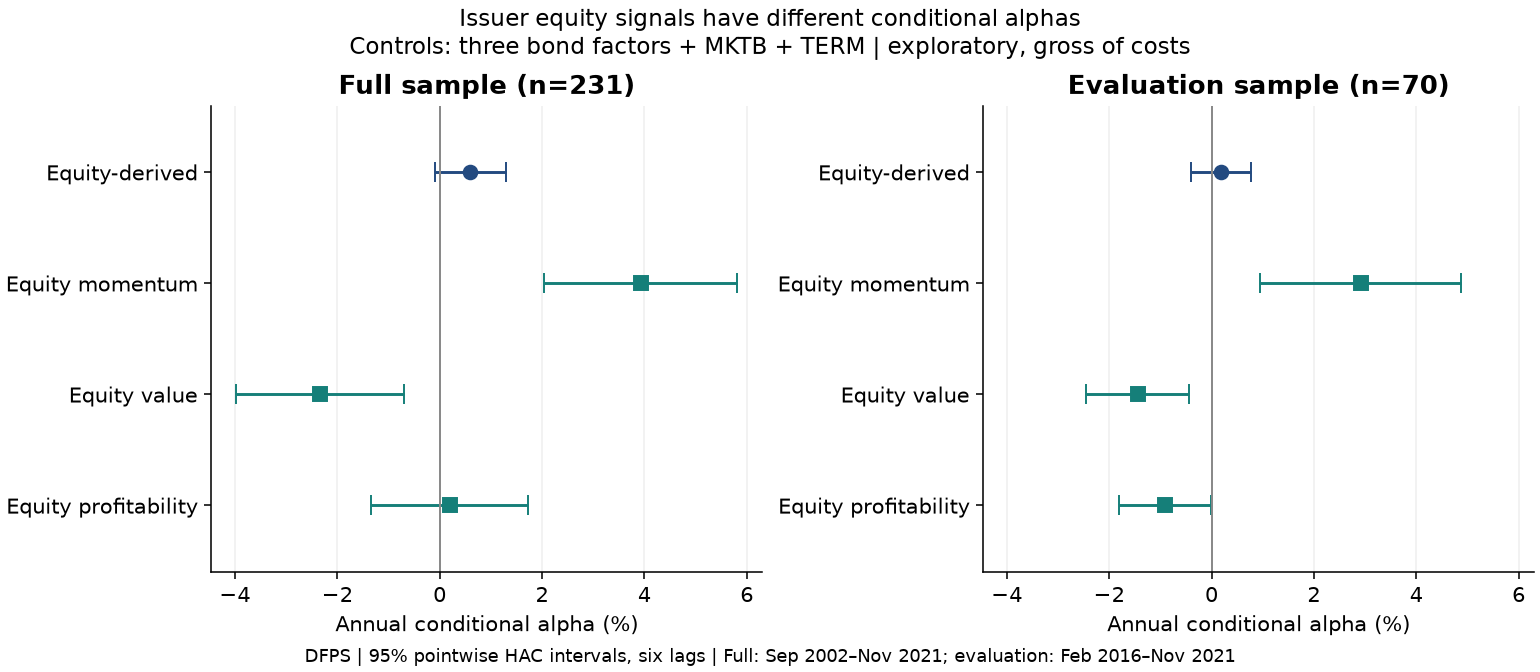

In [8]:
display(Image(filename=str(root / 'research/figures/incremental_alpha.png')))

Momentum and value have opposing conditional alphas. The composite remains
inconclusive. Both the regression controls and the testing family differ from the
original market/TERM-only analysis; a selected regression result is not a live strategy.

### 6. Compare with reducing bond exposure

The control scales bond-only exposure using the preceding 60 months. Unused reference
notional earns zero excess P&L. The realized risks need not match exactly.

In [9]:
controls = pd.read_csv(root / 'research/results/risk_control_performance.csv')
display(controls.loc[controls.dataset == 'DFPS',
    ['sample', 'n', 'strategy', 'annual_mean_pct', 'annual_vol_pct', 'sharpe']]
    .rename(columns={'annual_mean_pct': 'Mean %/year', 'annual_vol_pct': 'Vol %/year'})
    .round(3).reset_index(drop=True))

,sample,n,strategy,Mean %/year,Vol %/year,sharpe
0,Post-warmup,171,Combined,-0.118,2.689,-0.044
1,Post-warmup,171,Bond-only,-0.192,3.638,-0.053
2,Post-warmup,171,Risk-scaled bond,-0.210,2.760,-0.076
3,Evaluation,70,Combined,-0.460,2.067,-0.223
4,Evaluation,70,Bond-only,-0.542,3.130,-0.173
5,Evaluation,70,Risk-scaled bond,-0.323,2.168,-0.149


### 7. Cost headroom and paired uncertainty

Cost headroom is the mean difference versus the risk-scaled bond control, not an
estimate of transaction costs. The 50-bps threshold is an illustrative materiality
convention; the detectable effect is a normal/HAC precision approximation.

In [10]:
budget = pd.read_csv(root / 'research/results/incremental_cost_budget.csv')
display(budget.loc[(budget.dataset == 'DFPS') & (budget.control == 'Risk-scaled bond'),
    ['sample', 'annual_incremental_mean_bps', 'ci_low_bps', 'ci_high_bps', 'approximate_mde_80pct_bps']]
    .rename(columns={'annual_incremental_mean_bps': 'Mean bps/year', 'ci_low_bps': '95% low',
    'ci_high_bps': '95% high', 'approximate_mde_80pct_bps': '80% MDE bps/year'})
    .round(2).reset_index(drop=True))

,sample,Mean bps/year,95% low,95% high,80% MDE bps/year
0,Post-warmup,9.17,-33.65,51.98,61.20
1,Evaluation,-13.71,-51.62,24.19,54.18


Paired circular-block percentile intervals below are descriptive, conditional on realized paths and weights, and do not correct for selection.

In [11]:
intervals = pd.read_csv(root / 'research/results/sharpe_difference_intervals.csv')
display(intervals.loc[(intervals.dataset == 'DFPS') & (intervals.control == 'Risk-scaled bond'),
    ['sample', 'block_months', 'sharpe_difference', 'ci_low', 'ci_high']]
    .rename(columns={'block_months': 'Block months', 'sharpe_difference': 'Sharpe difference',
                     'ci_low': '95% low', 'ci_high': '95% high'})
    .round(3).reset_index(drop=True))

,sample,Block months,Sharpe difference,95% low,95% high
0,Post-warmup,6,0.032,-0.121,0.192
1,Post-warmup,12,0.032,-0.090,0.177
2,Evaluation,6,-0.074,-0.242,0.109
3,Evaluation,12,-0.074,-0.199,0.065


### 8. Paired source sensitivity

Same dates and signals; source agreement is dependent evidence.

In [12]:
source_pairs = pd.read_csv(root / 'research/results/paired_source_differences.csv')
display(source_pairs.loc[source_pairs['sample'] == 'Full',
    ['source_a', 'source_b', 'annual_mean_a_minus_b_bps', 'ci_low_bps', 'ci_high_bps', 'monthly_correlation']]
    .rename(columns={'annual_mean_a_minus_b_bps': 'A minus B bps/year', 'ci_low_bps': '95% low',
                     'ci_high_bps': '95% high', 'monthly_correlation': 'Correlation'})
    .round(3).reset_index(drop=True))

,source_a,source_b,A minus B bps/year,95% low,95% high,Correlation
0,DFPS,OSBAP,-2.851,-19.165,13.462,0.990
1,DFPS,ICE,-7.316,-28.620,13.987,0.977
2,OSBAP,ICE,-4.465,-20.556,11.627,0.975


## Takeaways

The archived source comparison reproduces exactly, but the chosen economic-direction
portfolio offers weak gross performance. Lower volatility is observable; reliable
incremental allocation benefit is not. The source-oriented version has different
exposures and cannot be substituted as evidence that the economic-direction hypothesis succeeded.

All three return sources produce a negative combined mean in the later period. The
factor-level diagnostics are complete. Positive conditional momentum alpha and
negative value alpha motivate a narrower question: issuer information transmission
versus common risk and stale prices. That follow-up requires matched security holdings,
point-in-time information, execution observations and an uninspected later sample.

No transaction-level TRACE cleaning, security-level integration, or estimated net-cost
backtest is claimed. Detailed provenance and scope are in [SOURCES.md](research/SOURCES.md).
